# Defensive Midfielder Profiling — Serie A (2021–2026)

## Aim
Translate a **qualitative player profile** into a **clear and measurable data profile** using Opta event-level data. Every metric must reflect a specific aspect of the role, avoiding redundancy or weak-meaning metrics. The final output is a ranked shortlist of Serie A players who best match the target profile.

### Target Profile — Ball-Winning Defensive Midfielder
| Characteristic | Description |
|---|---|
| **Possession regain** | Frequently regains possession through tackles or interceptions |
| **Positional screening** | Consistently positions to block passing lanes |
| **Counter-pressing** | Engages opponents quickly after possession loss |
| **Distribution security** | Keeps distribution simple and secure after recovery |

## Insights from Hvattum (2019): *"On the relationship between ratings and event-level data"*

Key findings relevant for building a defensive midfielder KPI framework:

1. **Tackles, interceptions, and clearances are strong positive predictors** of defensive player ratings — these are the most discriminating events for defenders and defensive midfielders.
2. **Simple passing accuracy positively correlates with ratings** for deeper midfielders — a DM who retains possession after winning it is rated higher.
3. **Fouls committed and dispossessions are negative predictors** — these represent failed defensive actions and loss of control, respectively.
4. **Per-match volume metrics must be normalized to per-90 minutes** to avoid minutes-bias — a player with 3000 minutes will naturally accumulate more events than one with 1500.
5. **Composite weighted indices outperform single metrics** — no single event type captures player quality; a weighted combination across pillars is more robust and discriminative.
6. **Position-group comparison is essential** — metrics must be compared within the same positional cluster (DM/CM) to be meaningful.

These findings directly justify our 4-pillar weighted framework: we emphasize ball-winning events (the strongest predictors), include positioning proxies, add counter-pressing intensity, and use passing accuracy as a secondary quality filter — all per 90 minutes.

## KPI Framework — Weighted Categories

The defensive midfielder's **primary job is screening the defence**, so ball-winning actions carry ~2.5× the weight of distribution metrics. The weights below reflect this hierarchy.

### Pillar 1 — Possession Regain (Weight = **0.40**)
| KPI | Opta Event | Sub-weight | Rationale |
|-----|-----------|------------|-----------|
| Tackles Won p90 | `type_id=7, outcome=1` | 0.15 | Direct dispossession of opponent |
| Interceptions p90 | `type_id=8` | 0.15 | Reading the game — cutting passing lanes proactively |
| Ball Recoveries p90 | `type_id=49` | 0.10 | Winning loose balls and second balls |

### Pillar 2 — Positional Screening (Weight = **0.25**)
| KPI | Opta Event | Sub-weight | Rationale |
|-----|-----------|------------|-----------|
| Blocked Passes p90 | `type_id=74` | 0.10 | Physically blocking opposition passing lanes |
| Clearances p90 | `type_id=12` | 0.08 | Emergency defensive interventions |
| Aerials Won % | `type_id=44, outcome=1 / total` | 0.07 | Aerial dominance in midfield zone |

### Pillar 3 — Counter-pressing (Weight = **0.20**)
| KPI | Opta Event | Sub-weight | Rationale |
|-----|-----------|------------|-----------|
| Ball Recoveries in Opp. Half p90 | `type_id=49, x > 50` | 0.10 | High pressing — regains in advanced areas |
| Tackles in Opp. Half p90 | `type_id=7, outcome=1, x > 50` | 0.10 | Aggressive engagement after turnovers |

### Pillar 4 — Distribution Security (Weight = **0.15**)
| KPI | Opta Event | Sub-weight | Rationale |
|-----|-----------|------------|-----------|
| Pass Completion % | `type_id=1, outcome=1 / total` | 0.05 | Accuracy of distribution |
| Short/Medium Pass % | `type_id=1, no "Long ball" qualifier` | 0.05 | Preference for safe, controlled passing |
| Turnovers p90 (**NEGATIVE**) | `type_id=50 + type_id=61 (outcome=0)` | 0.05 | Penalizes careless losses — *inverted in scoring* |

### Scoring Formula
$$S = 0.40 \cdot R_{\text{regain}} + 0.25 \cdot R_{\text{screen}} + 0.20 \cdot R_{\text{press}} + 0.15 \cdot R_{\text{dist}}$$

Where each $R$ is the weighted-average **percentile rank** (0–100) of the KPIs within that pillar, computed across all qualifying DMs/CMs with ≥ 900 minutes played.

In [1]:
# ── Cell 1: Imports & Configuration ──────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import glob
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from math import pi

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)

# ── Paths ────────────────────────────────────────────────────────────────────
BASE = os.path.abspath(os.path.join(os.getcwd(), ".."))
RAW  = os.path.join(BASE, "data", "raw")

SEASONS = sorted([
    d for d in os.listdir(RAW)
    if d.startswith("serie_a") and os.path.isdir(os.path.join(RAW, d, "events"))
])
print(f"Seasons found: {SEASONS}")

# ── Positions we consider as 'defensive midfield' ───────────────────────────
DM_POSITIONS = {"CDM", "MC"}   # CDM = classic DM, MC = central mid (often DM role)

# ── Minimum minutes threshold ───────────────────────────────────────────────
MIN_MINUTES = 900

# ── KPI weights ─────────────────────────────────────────────────────────────
PILLAR_WEIGHTS = {
    "Possession Regain":      0.40,
    "Positional Screening":   0.25,
    "Counter-pressing":       0.20,
    "Distribution Security":  0.15,
}

print("Setup complete ✓")

Seasons found: ['serie_a_2021_2022', 'serie_a_2022_2023', 'serie_a_2023_2024', 'serie_a_2024_2025', 'serie_a_2025_2026']
Setup complete ✓


## Load and Parse Serie A Event Data

We iterate over all season folders, load every match CSV, and keep only events from players whose `position` is in `{CDM, MC}`. We also compute approximate **minutes played** per player per season from their event timestamps.

In [2]:
# ── Cell 2: Load all events & filter for DM positions ───────────────────────

def load_all_events(seasons, raw_path, dm_positions):
    """Load events from all seasons, keeping only DM-position players."""
    frames = []
    for season in seasons:
        evt_dir = os.path.join(raw_path, season, "events")
        files = glob.glob(os.path.join(evt_dir, "*.csv"))
        print(f"  {season}: {len(files)} match files")
        for f in files:
            try:
                df = pd.read_csv(f, low_memory=False)
                df["season"] = season.replace("serie_a_", "")
                # Extract gameweek from filename
                df["gameweek"] = os.path.basename(f).split("_")[0]
                frames.append(df)
            except Exception as e:
                continue
    
    print(f"\nConcatenating {len(frames)} files...")
    all_events = pd.concat(frames, ignore_index=True)
    print(f"Total events: {len(all_events):,}")
    
    # Filter for DM positions
    dm_events = all_events[all_events["position"].isin(dm_positions)].copy()
    print(f"DM/CM events: {len(dm_events):,}")
    print(f"Unique players: {dm_events['player_name'].nunique()}")
    
    return all_events, dm_events

all_events, dm_events = load_all_events(SEASONS, RAW, DM_POSITIONS)

  serie_a_2021_2022: 380 match files
  serie_a_2022_2023: 381 match files
  serie_a_2022_2023: 381 match files
  serie_a_2023_2024: 380 match files
  serie_a_2023_2024: 380 match files
  serie_a_2024_2025: 380 match files
  serie_a_2024_2025: 380 match files
  serie_a_2025_2026: 319 match files
  serie_a_2025_2026: 319 match files

Concatenating 1840 files...

Concatenating 1840 files...
Total events: 3,158,433
Total events: 3,158,433
DM/CM events: 588,984
Unique players: 512
DM/CM events: 588,984
Unique players: 512


In [3]:
# ── Cell 3: Estimate minutes played per player-season ───────────────────────

def estimate_minutes(dm_events):
    """
    Estimate minutes played per player per season.
    We count distinct matches and use max(time_min) per match as proxy.
    """
    dm = dm_events.copy()
    dm["time_min"] = pd.to_numeric(dm["time_min"], errors="coerce")
    
    # Minutes per player per match: use the max event minute for that player
    player_match = (
        dm.groupby(["player_name", "player_id", "team_name", "season", "match_id"])
        ["time_min"]
        .max()
        .reset_index()
        .rename(columns={"time_min": "last_event_min"})
    )
    
    # Aggregate across matches
    minutes_df = (
        player_match
        .groupby(["player_name", "player_id", "team_name", "season"])
        .agg(
            matches=("match_id", "nunique"),
            total_minutes=("last_event_min", "sum"),
        )
        .reset_index()
    )
    
    print(f"Player-season combinations: {len(minutes_df)}")
    print(f"After {MIN_MINUTES}-min filter: {(minutes_df['total_minutes'] >= MIN_MINUTES).sum()}")
    
    return minutes_df

minutes_df = estimate_minutes(dm_events)
minutes_df.sort_values("total_minutes", ascending=False).head(10)

Player-season combinations: 1008
After 900-min filter: 364


,player_name,player_id,team_name,season,matches,total_minutes
594,M. Guendouzi,asvqr3i5wcjiajxipt1qvldyh,SS Lazio,2024_2025,37,3296
792,R. Freuler,19nlw3sa0khwz0el4wqc7zrp,Bologna FC 1909,2024_2025,37,3253
854,S. Lobotka,9y8fnvazj02vy31ljx3du0d79,SSC Napoli,2023_2024,37,3243
868,S. Milinković-Savić,dkifo6kxxxsv1hr0rzk1q8afp,SS Lazio,2021_2022,37,3224
869,S. Milinković-Savić,dkifo6kxxxsv1hr0rzk1q8afp,SS Lazio,2022_2023,36,3220
853,S. Lobotka,9y8fnvazj02vy31ljx3du0d79,SSC Napoli,2022_2023,36,3194
78,A. Tamèze,9sjt5rv156hr2llfu241r6cph,Hellas Verona FC,2022_2023,37,3142
596,M. Hjulmand,4x1tm440b5cshi5gxkx5k9m95,US Lecce,2022_2023,35,3127
238,F. Anguissa,3bhy6x04rbwzk0nh1fm59dmnd,SSC Napoli,2022_2023,36,3120
240,F. Anguissa,3bhy6x04rbwzk0nh1fm59dmnd,SSC Napoli,2024_2025,35,3106


## Engineer Defensive Midfield KPIs from Events

We compute all raw KPI counts per player-season, then normalize to **per 90 minutes**.

In [4]:
# ── Cell 4: Compute raw KPI counts per player-season ────────────────────────

def compute_raw_kpis(dm_events):
    """Compute all needed raw counts per player-season from Opta events."""
    df = dm_events.copy()
    df["type_id"] = pd.to_numeric(df["type_id"], errors="coerce")
    df["outcome"]  = pd.to_numeric(df["outcome"], errors="coerce")
    df["x"]        = pd.to_numeric(df["x"], errors="coerce")
    
    grp = ["player_name", "player_id", "team_name", "season"]
    
    # Helper: count events matching conditions
    def count_events(mask):
        return df[mask].groupby(grp).size()
    
    kpis = pd.DataFrame()
    
    # ── Pillar 1: Possession Regain ──
    kpis["tackles_won"]       = count_events((df["type_id"] == 7) & (df["outcome"] == 1))
    kpis["interceptions"]     = count_events(df["type_id"] == 8)
    kpis["ball_recoveries"]   = count_events(df["type_id"] == 49)
    
    # ── Pillar 2: Positional Screening ──
    kpis["blocked_passes"]    = count_events(df["type_id"] == 74)
    kpis["clearances"]        = count_events(df["type_id"] == 12)
    kpis["aerials_won"]       = count_events((df["type_id"] == 44) & (df["outcome"] == 1))
    kpis["aerials_total"]     = count_events(df["type_id"] == 44)
    
    # ── Pillar 3: Counter-pressing ──
    kpis["ball_rec_opp_half"] = count_events((df["type_id"] == 49) & (df["x"] > 50))
    kpis["tackles_opp_half"]  = count_events((df["type_id"] == 7) & (df["outcome"] == 1) & (df["x"] > 50))
    
    # ── Pillar 4: Distribution Security ──
    kpis["passes_completed"]  = count_events((df["type_id"] == 1) & (df["outcome"] == 1))
    kpis["passes_total"]      = count_events(df["type_id"] == 1)
    # Short/medium passes = passes WITHOUT "Long ball" qualifier
    kpis["short_passes"]      = count_events(
        (df["type_id"] == 1) & (df["outcome"] == 1) & (df["Long ball"].isin(["N/A", np.nan]))
    )
    # Turnovers (negative): dispossessed + bad touches
    kpis["turnovers"]         = count_events(
        (df["type_id"] == 50) | ((df["type_id"] == 61) & (df["outcome"] == 0))
    )
    # Fouls committed (negative, for reference)
    kpis["fouls_committed"]   = count_events(
        (df["type_id"] == 4) & (df["outcome"] == 0)  # outcome 0 = committed
    )
    
    kpis = kpis.fillna(0).reset_index()
    return kpis

raw_kpis = compute_raw_kpis(dm_events)
print(f"Raw KPIs computed for {len(raw_kpis)} player-seasons")
raw_kpis.head()

Raw KPIs computed for 736 player-seasons


,player_name,player_id,team_name,season,tackles_won,interceptions,ball_recoveries,blocked_passes,clearances,aerials_won,aerials_total,ball_rec_opp_half,tackles_opp_half,passes_completed,passes_total,short_passes,turnovers,fouls_committed
0,A. Atta,2wwbf11c9mc2psxaa8p58qnmc,Udinese Calcio,2024_2025,1,0.0,12.0,3.0,3.0,3.0,6.0,5.0,0.0,108.0,125,107.0,10.0,4.0
1,A. Atta,2wwbf11c9mc2psxaa8p58qnmc,Udinese Calcio,2025_2026,8,9.0,46.0,9.0,18.0,8.0,14.0,20.0,5.0,370.0,475,345.0,66.0,11.0
2,A. Barák,963czsr3yecwk4s3p1wby5x3p,ACF Fiorentina,2022_2023,6,3.0,35.0,6.0,7.0,4.0,15.0,19.0,5.0,302.0,354,281.0,30.0,4.0
3,A. Barák,963czsr3yecwk4s3p1wby5x3p,Hellas Verona FC,2021_2022,1,0.0,11.0,5.0,6.0,4.0,7.0,1.0,1.0,55.0,74,53.0,6.0,0.0
4,A. Bernede,alrmqpg2y5f7xqqpgubwvx0q1,Hellas Verona FC,2024_2025,6,3.0,24.0,2.0,3.0,3.0,6.0,5.0,3.0,116.0,153,107.0,11.0,12.0


In [5]:
# ── Cell 5: Merge with minutes & compute per-90 metrics ─────────────────────

def compute_per90(raw_kpis, minutes_df, min_minutes=900):
    """Merge raw counts with minutes, filter, and normalize to per-90."""
    merged = raw_kpis.merge(
        minutes_df[["player_name", "player_id", "season", "matches", "total_minutes"]],
        on=["player_name", "player_id", "season"],
        how="left"
    )
    
    # Filter for minimum minutes
    df = merged[merged["total_minutes"] >= min_minutes].copy()
    print(f"Players after {min_minutes}-min filter: {len(df)}")
    
    # Per-90 columns
    per90_cols = [
        "tackles_won", "interceptions", "ball_recoveries",
        "blocked_passes", "clearances",
        "ball_rec_opp_half", "tackles_opp_half",
        "turnovers", "fouls_committed"
    ]
    
    for col in per90_cols:
        df[f"{col}_p90"] = (df[col] / df["total_minutes"]) * 90
    
    # Rate metrics (not per-90 but ratios)
    df["pass_completion_pct"] = (df["passes_completed"] / df["passes_total"] * 100).fillna(0)
    df["short_pass_pct"]      = (df["short_passes"] / df["passes_completed"] * 100).fillna(0)
    df["aerial_win_pct"]      = (df["aerials_won"] / df["aerials_total"] * 100).fillna(0)
    
    return df

player_stats = compute_per90(raw_kpis, minutes_df, MIN_MINUTES)
player_stats.sort_values("tackles_won_p90", ascending=False).head(10)[
    ["player_name", "team_name", "season", "matches", "total_minutes",
     "tackles_won_p90", "interceptions_p90", "ball_recoveries_p90", "pass_completion_pct"]
]

Players after 900-min filter: 370


,player_name,team_name,season,matches,total_minutes,tackles_won_p90,interceptions_p90,ball_recoveries_p90,pass_completion_pct
450,M. Locatelli,Juventus FC,2025_2026,29,2371,2.125685,1.100801,4.744833,88.412853
516,N. Domínguez,Bologna FC 1909,2021_2022,20,1642,2.082826,1.205847,6.084044,84.056272
241,H. Rafia,US Lecce,2023_2024,14,921,1.856678,0.684039,4.690554,72.789116
342,Kike Pérez,Venezia FC,2024_2025,14,1126,1.838366,0.799290,5.595027,74.255692
75,B. Cristante,AS Roma,2022_2023,32,2731,1.812523,0.395460,6.129623,82.270916
670,S. Serdar,Hellas Verona FC,2023_2024,19,1619,1.778876,0.833848,4.725139,73.483146
426,M. Frendrup,Genoa CFC,2023_2024,31,2638,1.774071,1.262320,4.571645,81.847826
46,A. Rabiot,Juventus FC,2021_2022,16,1392,1.745690,0.775862,6.012931,81.705151
428,M. Frendrup,Genoa CFC,2025_2026,20,1704,1.742958,0.950704,2.904930,84.749035
517,N. Domínguez,Bologna FC 1909,2022_2023,25,2059,1.704711,0.743079,5.463817,83.569405


## Percentile Ranking & KPI Distributions

We convert every KPI to a **percentile rank** (0–100) across all qualifying DMs. For **negative metrics** (turnovers, fouls), we invert the percentile so that *lower is better*.

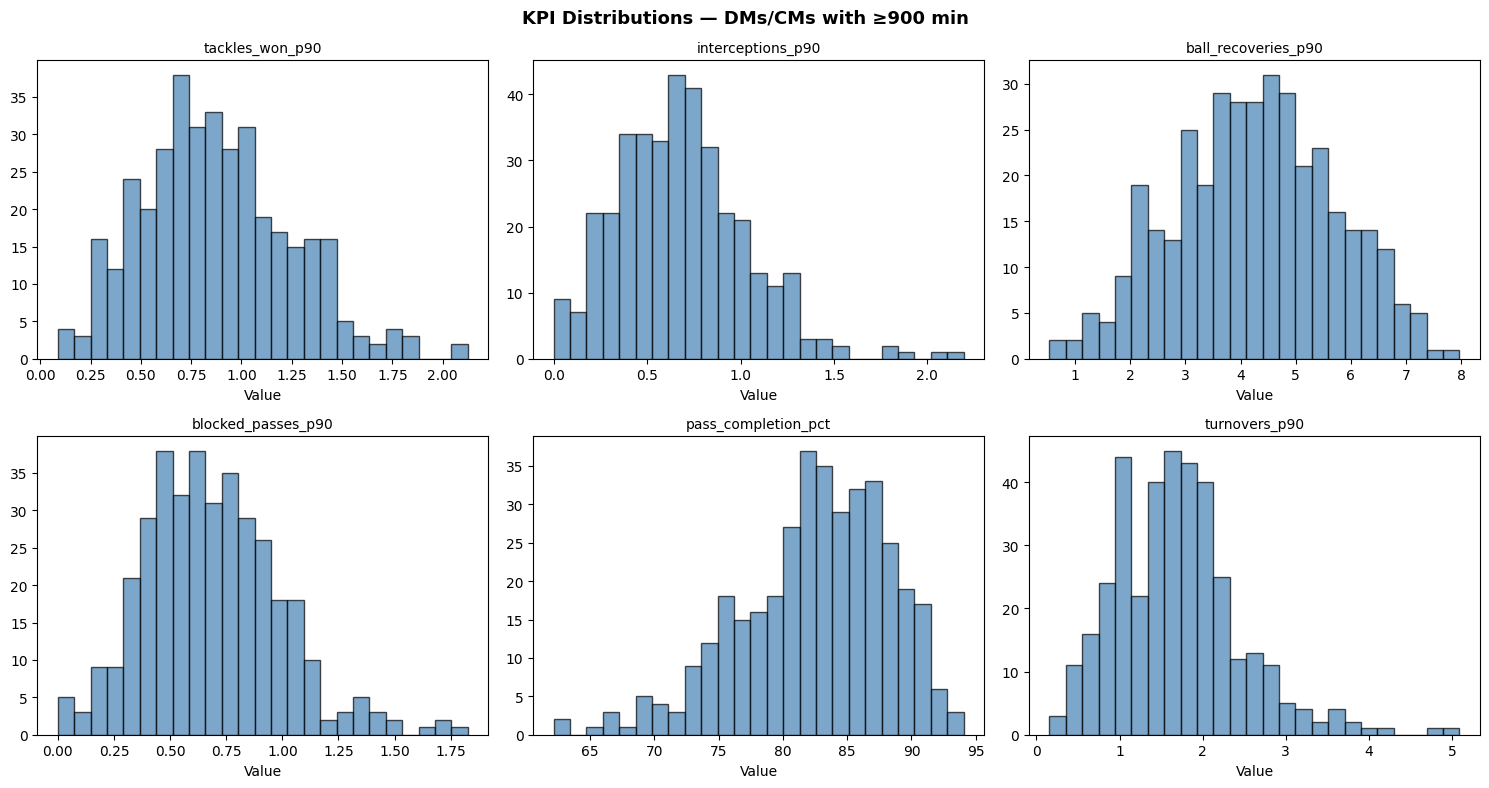

In [6]:
# ── Cell 6: Percentile ranking ───────────────────────────────────────────────

# KPIs for each pillar and whether they are positive or negative
KPI_MAP = {
    "Possession Regain": {
        "tackles_won_p90":       {"weight": 0.15 / 0.40, "negative": False},
        "interceptions_p90":     {"weight": 0.15 / 0.40, "negative": False},
        "ball_recoveries_p90":   {"weight": 0.10 / 0.40, "negative": False},
    },
    "Positional Screening": {
        "blocked_passes_p90":    {"weight": 0.10 / 0.25, "negative": False},
        "clearances_p90":        {"weight": 0.08 / 0.25, "negative": False},
        "aerial_win_pct":        {"weight": 0.07 / 0.25, "negative": False},
    },
    "Counter-pressing": {
        "ball_rec_opp_half_p90": {"weight": 0.10 / 0.20, "negative": False},
        "tackles_opp_half_p90":  {"weight": 0.10 / 0.20, "negative": False},
    },
    "Distribution Security": {
        "pass_completion_pct":   {"weight": 0.05 / 0.15, "negative": False},
        "short_pass_pct":        {"weight": 0.05 / 0.15, "negative": False},
        "turnovers_p90":         {"weight": 0.05 / 0.15, "negative": True},
    },
}

def compute_percentiles(df, kpi_map):
    """Compute percentile ranks for all KPIs. Invert negative ones."""
    result = df.copy()
    
    for pillar, kpis in kpi_map.items():
        for kpi, info in kpis.items():
            pct_col = f"{kpi}_pct"
            result[pct_col] = result[kpi].rank(pct=True) * 100
            if info["negative"]:
                result[pct_col] = 100 - result[pct_col]  # invert: lower turnovers = higher percentile
    
    return result

player_pct = compute_percentiles(player_stats, KPI_MAP)

# Show distributions of key metrics
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_metrics = ["tackles_won_p90", "interceptions_p90", "ball_recoveries_p90",
               "blocked_passes_p90", "pass_completion_pct", "turnovers_p90"]
for ax, metric in zip(axes.flat, key_metrics):
    ax.hist(player_pct[metric].dropna(), bins=25, edgecolor="black", alpha=0.7, color="steelblue")
    ax.set_title(metric, fontsize=10)
    ax.set_xlabel("Value")
plt.suptitle("KPI Distributions — DMs/CMs with ≥900 min", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
# ── Cell 7: Build Weighted Composite Score ───────────────────────────────────

def build_composite_score(df, kpi_map, pillar_weights):
    """Compute pillar scores and final weighted composite."""
    result = df.copy()
    
    for pillar, kpis in kpi_map.items():
        pillar_score = np.zeros(len(result))
        for kpi, info in kpis.items():
            pct_col = f"{kpi}_pct"
            pillar_score += result[pct_col].values * info["weight"]
        col_name = f"pillar_{pillar.replace(' ', '_').lower()}"
        result[col_name] = pillar_score
    
    # Final composite
    result["composite_score"] = (
        result["pillar_possession_regain"]      * pillar_weights["Possession Regain"] +
        result["pillar_positional_screening"]   * pillar_weights["Positional Screening"] +
        result["pillar_counter-pressing"]       * pillar_weights["Counter-pressing"] +
        result["pillar_distribution_security"]  * pillar_weights["Distribution Security"]
    )
    
    return result.sort_values("composite_score", ascending=False)

scored = build_composite_score(player_pct, KPI_MAP, PILLAR_WEIGHTS)

# Display top 20
display_cols = [
    "player_name", "team_name", "season", "matches", "total_minutes",
    "tackles_won_p90", "interceptions_p90", "ball_recoveries_p90",
    "blocked_passes_p90", "pass_completion_pct", "turnovers_p90",
    "pillar_possession_regain", "pillar_positional_screening",
    "pillar_counter-pressing", "pillar_distribution_security",
    "composite_score"
]

print("═" * 80)
print("  TOP 20 DEFENSIVE MIDFIELDERS — WEIGHTED COMPOSITE RANKING")
print("═" * 80)
scored[display_cols].head(20).round(2)

════════════════════════════════════════════════════════════════════════════════
  TOP 20 DEFENSIVE MIDFIELDERS — WEIGHTED COMPOSITE RANKING
════════════════════════════════════════════════════════════════════════════════


,player_name,team_name,season,matches,total_minutes,tackles_won_p90,interceptions_p90,ball_recoveries_p90,blocked_passes_p90,pass_completion_pct,turnovers_p90,pillar_possession_regain,pillar_positional_screening,pillar_counter-pressing,pillar_distribution_security,composite_score
497,M. de Roon,Atalanta Bergamasca Calcio,2021_2022,25,2152,1.21,1.51,6.11,1.05,84.82,0.67,89.59,84.35,87.84,63.60,84.03
136,E. Barrenechea,Frosinone Calcio,2023_2024,31,2752,1.28,0.82,7.29,1.05,85.46,1.05,82.74,89.48,86.35,68.65,83.03
591,R. Freuler,Atalanta Bergamasca Calcio,2021_2022,29,2470,1.38,1.28,6.74,1.46,86.28,2.33,93.51,66.45,98.51,59.82,82.69
516,N. Domínguez,Bologna FC 1909,2021_2022,20,1642,2.08,1.21,6.08,0.99,84.06,1.75,94.09,81.13,90.81,40.81,82.20
427,M. Frendrup,Genoa CFC,2024_2025,34,3022,1.64,1.31,5.03,1.34,85.67,1.73,90.37,77.16,83.78,66.22,82.13
771,Y. Ramadani,US Lecce,2025_2026,31,2730,1.35,1.29,5.54,1.12,79.54,1.81,89.29,88.56,94.73,32.07,81.61
379,Lucas Leiva,SS Lazio,2021_2022,23,1763,1.28,1.23,5.05,0.77,91.89,0.51,84.63,79.00,69.59,93.42,81.53
432,M. Hjulmand,US Lecce,2022_2023,35,3127,1.50,2.07,7.25,0.92,78.73,1.38,98.04,83.37,78.92,33.33,80.84
9,A. Blin,US Lecce,2022_2023,26,2141,1.43,1.18,4.75,1.47,78.47,1.85,85.17,82.17,90.41,46.31,79.64
600,R. Krunić,AC Milan,2022_2023,18,1541,1.40,0.76,6.89,0.99,86.27,0.70,81.59,68.46,84.73,83.56,79.23


## Radar Charts — Top Candidates

Visualize the **4 pillar scores** for the top 10 players as radar/spider charts.

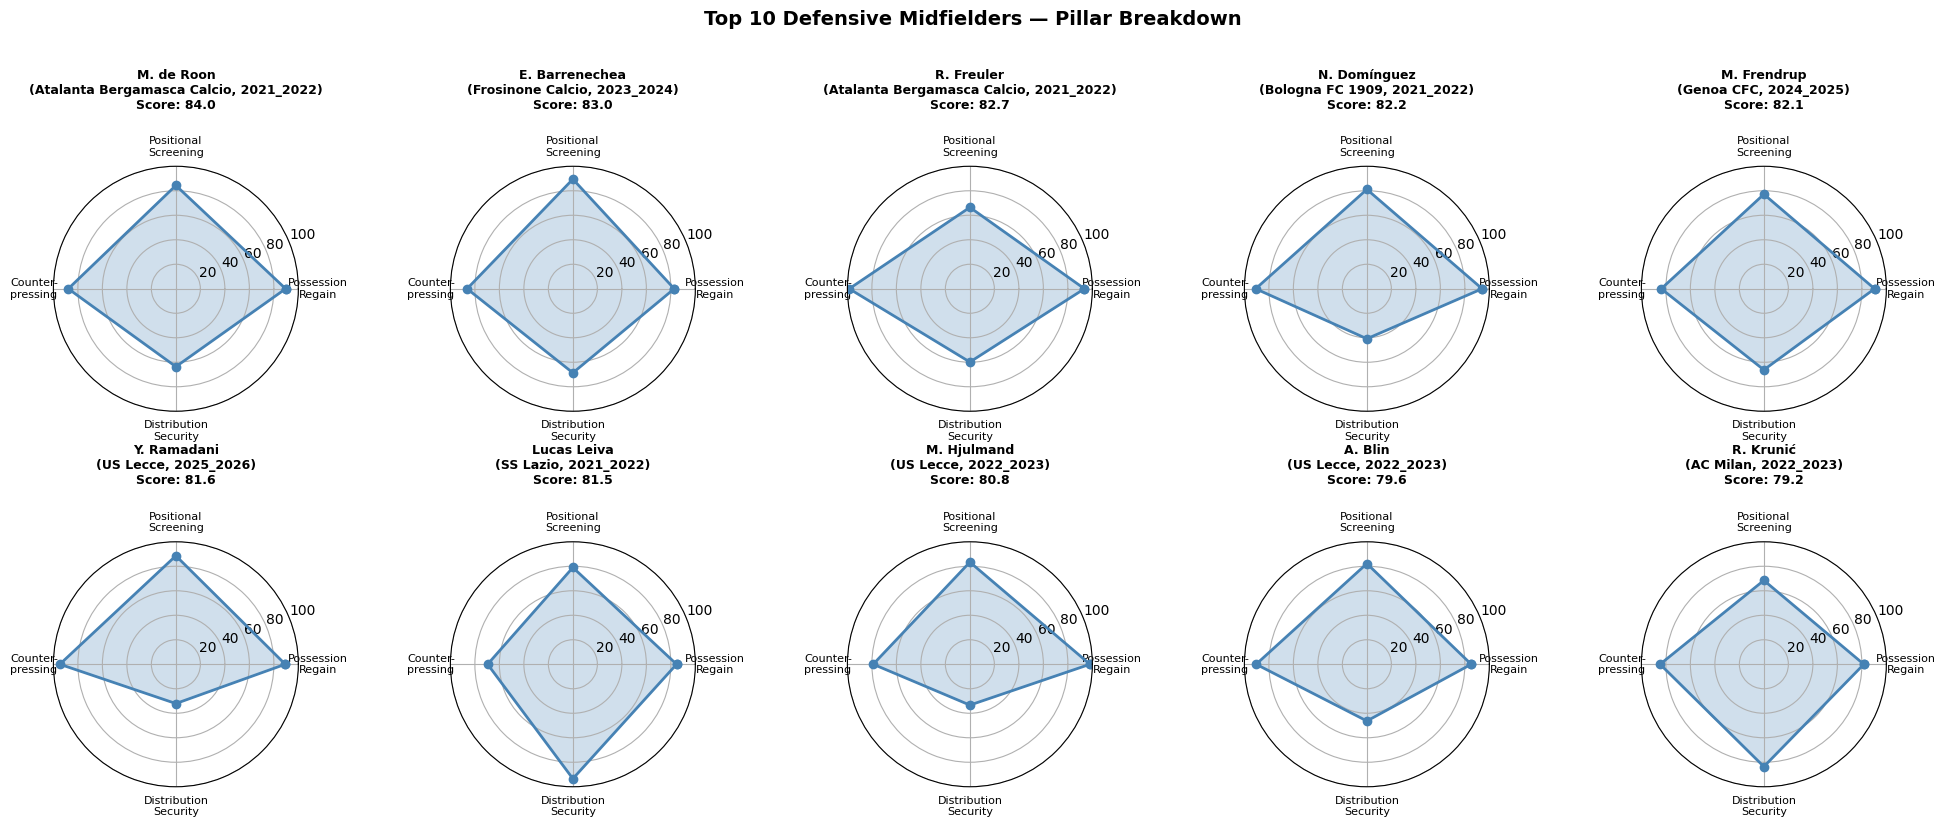

In [8]:
# ── Cell 8: Radar charts for top 10 players ──────────────────────────────────

pillar_cols = [
    "pillar_possession_regain",
    "pillar_positional_screening",
    "pillar_counter-pressing",
    "pillar_distribution_security",
]
pillar_labels = ["Possession\nRegain", "Positional\nScreening", "Counter-\npressing", "Distribution\nSecurity"]

def radar_chart(players_df, pillar_cols, pillar_labels, title=""):
    """Create radar charts for multiple players."""
    n_players = len(players_df)
    cols = min(5, n_players)
    rows = (n_players + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows),
                              subplot_kw=dict(polar=True))
    if n_players == 1:
        axes = np.array([axes])
    axes = axes.flat
    
    N = len(pillar_cols)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    for idx, (_, row) in enumerate(players_df.iterrows()):
        ax = axes[idx]
        values = [row[c] for c in pillar_cols]
        values += values[:1]
        
        ax.plot(angles, values, "o-", linewidth=2, color="steelblue")
        ax.fill(angles, values, alpha=0.25, color="steelblue")
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(pillar_labels, fontsize=8)
        ax.set_ylim(0, 100)
        ax.set_title(f"{row['player_name']}\n({row['team_name']}, {row['season']})\nScore: {row['composite_score']:.1f}",
                     fontsize=9, fontweight="bold", pad=20)
    
    # Hide unused axes
    for idx in range(n_players, len(list(axes))):
        axes[idx].set_visible(False)
    
    plt.suptitle(title, fontsize=14, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()

# Top 10 individual radars
radar_chart(scored.head(10), pillar_cols, pillar_labels,
            title="Top 10 Defensive Midfielders — Pillar Breakdown")

In [9]:
# ── Cell 9: Filter candidates & apply minimum thresholds ─────────────────────

def filter_candidates(df):
    """
    Apply minimum thresholds:
    - Possession Regain pillar ≥ 70th percentile
    - Distribution Security ≥ 50th percentile
    - No single defensive KPI below 40th percentile
    """
    defensive_pct_cols = [
        "tackles_won_p90_pct", "interceptions_p90_pct", "ball_recoveries_p90_pct",
        "blocked_passes_p90_pct", "clearances_p90_pct",
        "ball_rec_opp_half_p90_pct", "tackles_opp_half_p90_pct"
    ]
    
    mask = (
        (df["pillar_possession_regain"] >= 70) &
        (df["pillar_distribution_security"] >= 50) &
        (df[defensive_pct_cols].min(axis=1) >= 40)
    )
    
    filtered = df[mask].copy()
    print(f"Candidates passing all thresholds: {len(filtered)}")
    return filtered

candidates = filter_candidates(scored)

# Display ranked candidates
cand_cols = [
    "player_name", "team_name", "season", "matches", "total_minutes",
    "composite_score",
    "pillar_possession_regain", "pillar_positional_screening",
    "pillar_counter-pressing", "pillar_distribution_security",
]
candidates[cand_cols].head(20).round(1)

Candidates passing all thresholds: 17


,player_name,team_name,season,matches,total_minutes,composite_score,pillar_possession_regain,pillar_positional_screening,pillar_counter-pressing,pillar_distribution_security
497,M. de Roon,Atalanta Bergamasca Calcio,2021_2022,25,2152,84.0,89.6,84.3,87.8,63.6
136,E. Barrenechea,Frosinone Calcio,2023_2024,31,2752,83.0,82.7,89.5,86.4,68.6
591,R. Freuler,Atalanta Bergamasca Calcio,2021_2022,29,2470,82.7,93.5,66.5,98.5,59.8
427,M. Frendrup,Genoa CFC,2024_2025,34,3022,82.1,90.4,77.2,83.8,66.2
379,Lucas Leiva,SS Lazio,2021_2022,23,1763,81.5,84.6,79.0,69.6,93.4
600,R. Krunić,AC Milan,2022_2023,18,1541,79.2,81.6,68.5,84.7,83.6
499,M. de Roon,Atalanta Bergamasca Calcio,2023_2024,25,2295,78.1,85.7,83.7,73.9,54.2
301,J. Schouten,Bologna FC 1909,2022_2023,28,2415,77.9,94.4,70.3,65.9,62.5
498,M. de Roon,Atalanta Bergamasca Calcio,2022_2023,33,2951,76.5,84.9,87.7,64.2,52.2
159,F. Anguissa,SSC Napoli,2021_2022,23,2109,75.0,78.1,83.7,66.9,63.0


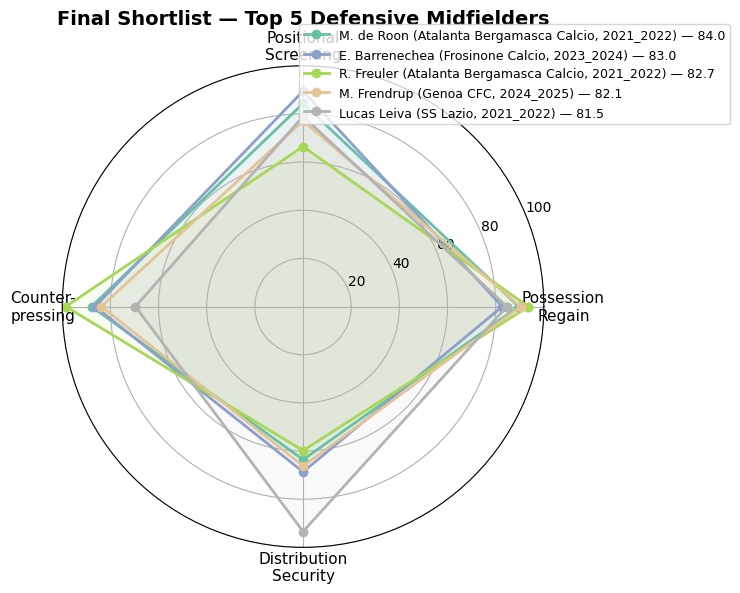

In [10]:
# ── Cell 10: Overlay radar — Top 5 shortlisted players ───────────────────────

def overlay_radar(players_df, pillar_cols, pillar_labels, title=""):
    """Single radar chart with all players overlaid for comparison."""
    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    
    N = len(pillar_cols)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    colors = plt.cm.Set2(np.linspace(0, 1, len(players_df)))
    
    for (_, row), color in zip(players_df.iterrows(), colors):
        values = [row[c] for c in pillar_cols]
        values += values[:1]
        label = f"{row['player_name']} ({row['team_name']}, {row['season']}) — {row['composite_score']:.1f}"
        ax.plot(angles, values, "o-", linewidth=2, color=color, label=label)
        ax.fill(angles, values, alpha=0.08, color=color)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(pillar_labels, fontsize=11)
    ax.set_ylim(0, 100)
    ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.1), fontsize=9)
    ax.set_title(title, fontsize=14, fontweight="bold", pad=30)
    plt.tight_layout()
    plt.show()

# Top 5 overlay
top5 = candidates.head(5)
overlay_radar(top5, pillar_cols, pillar_labels,
              title="Final Shortlist — Top 5 Defensive Midfielders")

In [11]:
# ── Cell 11: Summary cards for top 5 ─────────────────────────────────────────

print("=" * 80)
print("  FINAL SHORTLIST — DEFENSIVE MIDFIELDER PROFILE MATCH")
print("=" * 80)

for rank, (_, p) in enumerate(top5.iterrows(), 1):
    print(f"\n{'─' * 60}")
    print(f"  #{rank}  {p['player_name']}  |  {p['team_name']}  |  {p['season']}")
    print(f"{'─' * 60}")
    print(f"  Matches: {p['matches']:.0f}   |   Minutes: {p['total_minutes']:.0f}")
    print(f"  COMPOSITE SCORE: {p['composite_score']:.1f} / 100")
    print(f"")
    print(f"  Possession Regain:      {p['pillar_possession_regain']:.1f}")
    print(f"  Positional Screening:   {p['pillar_positional_screening']:.1f}")
    print(f"  Counter-pressing:       {p['pillar_counter-pressing']:.1f}")
    print(f"  Distribution Security:  {p['pillar_distribution_security']:.1f}")
    print(f"")
    print(f"  Key stats p90: Tackles Won={p['tackles_won_p90']:.2f}  "
          f"Interceptions={p['interceptions_p90']:.2f}  "
          f"Ball Rec.={p['ball_recoveries_p90']:.2f}  "
          f"Pass%={p['pass_completion_pct']:.1f}%")

print(f"\n{'=' * 80}")

  FINAL SHORTLIST — DEFENSIVE MIDFIELDER PROFILE MATCH

────────────────────────────────────────────────────────────
  #1  M. de Roon  |  Atalanta Bergamasca Calcio  |  2021_2022
────────────────────────────────────────────────────────────
  Matches: 25   |   Minutes: 2152
  COMPOSITE SCORE: 84.0 / 100

  Possession Regain:      89.6
  Positional Screening:   84.3
  Counter-pressing:       87.8
  Distribution Security:  63.6

  Key stats p90: Tackles Won=1.21  Interceptions=1.51  Ball Rec.=6.11  Pass%=84.8%

────────────────────────────────────────────────────────────
  #2  E. Barrenechea  |  Frosinone Calcio  |  2023_2024
────────────────────────────────────────────────────────────
  Matches: 31   |   Minutes: 2752
  COMPOSITE SCORE: 83.0 / 100

  Possession Regain:      82.7
  Positional Screening:   89.5
  Counter-pressing:       86.4
  Distribution Security:  68.6

  Key stats p90: Tackles Won=1.28  Interceptions=0.82  Ball Rec.=7.29  Pass%=85.5%

──────────────────────────────────

## Passes-to-Regain (PTR) — Individual Counter-pressing Metric

**Concept** (inspired by the PPDA logic in the dashboard):

1. We detect every **possession change** in a match — the moment team A loses the ball to team B.
2. We count how many **passes team B completes** before team A wins it back.
3. We attribute the regain to the **individual player** who performed the recovery action (tackle, interception, or ball recovery).
4. Each player accumulates a distribution of PTR values. Players whose **median PTR is lower** are the most effective counter-pressers — they (or their team around them) win the ball back fastest.

### Key differences from PPDA
| | PPDA (dashboard) | PTR (this notebook) |
|---|---|---|
| Zone | Final-third pressing zone only | **Entire field** |
| Unit | Team-level | **Player-level** |
| Metric | Passes allowed per recovery | **Opponent passes between loss and individual regain** |
| Purpose | Team pressing intensity | **Individual counter-pressing speed** |

In [12]:
# ── Cell 12: Compute Passes-to-Regain (PTR) per individual player ────────────
#
# Logic (adapted from PPDA possession-change detection):
#   1. Sort events chronologically within each match.
#   2. Identify the "possessing team" via a forward-fill on passes/regains.
#   3. Detect possession changes (team A → team B).
#   4. For each loss event, count opponent *completed* passes until the
#      losing team regains. Attribute the regain to the player who did it.
#
# We work on all_events (entire field, all positions) to correctly track
# possession chains, then filter results down to DM/CM players.

def compute_passes_to_regain(all_events, dm_positions, min_minutes_df=None):
    """
    Compute individual Passes-To-Regain (PTR) for defensive midfielders.
    
    Returns a DataFrame with one row per regain event:
        match_id, season, regain_team, regain_player, regain_player_id,
        regain_position, opp_passes_before_regain, regain_type, regain_x
    """
    # ── Prepare events ───────────────────────────────────────
    ev = all_events.copy()
    ev["type_id"]  = pd.to_numeric(ev["type_id"], errors="coerce")
    ev["outcome"]  = pd.to_numeric(ev["outcome"], errors="coerce")
    ev["time_min"] = pd.to_numeric(ev["time_min"], errors="coerce")
    ev["time_sec"] = pd.to_numeric(ev["time_sec"], errors="coerce")
    ev["x"]        = pd.to_numeric(ev["x"], errors="coerce")
    ev["period_id"] = pd.to_numeric(ev["period_id"], errors="coerce")
    
    # Drop non-play events (setups, starts, ends, etc.)
    play_types = {1, 2, 3, 4, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16,
                  41, 44, 45, 49, 50, 51, 54, 61, 74}
    ev = ev[ev["type_id"].isin(play_types)].copy()
    ev = ev.dropna(subset=["match_id", "team_name", "period_id", "time_min"])
    
    # Sort chronologically
    ev["t_sec"] = ev["time_min"] * 60 + ev["time_sec"].fillna(0)
    ev = ev.sort_values(["match_id", "period_id", "t_sec", "event_id"]).reset_index(drop=True)
    
    # ── Possession proxy ─────────────────────────────────────
    # A team "has possession" after a successful pass (type 1, outcome 1)
    # or a ball recovery (type 49), tackle won (type 7, outcome 1),
    # interception (type 8), or a goal kick / claim / GK pickup.
    possession_mask = (
        ((ev["type_id"] == 1) & (ev["outcome"] == 1)) |  # successful pass
        (ev["type_id"] == 49) |                           # ball recovery
        ((ev["type_id"] == 7) & (ev["outcome"] == 1)) |  # tackle won
        (ev["type_id"] == 8) |                            # interception
        (ev["type_id"] == 11) |                           # GK claim
        (ev["type_id"] == 52)                             # GK pick-up
    )
    
    ev["pos_team"] = np.where(possession_mask, ev["team_name"], np.nan)
    ev["pos_team"] = ev.groupby(["match_id", "period_id"])["pos_team"].ffill()
    
    # ── Detect possession changes ────────────────────────────
    ev["prev_pos_team"] = ev.groupby(["match_id", "period_id"])["pos_team"].shift(1)
    ev["pos_change"] = (
        (ev["pos_team"] != ev["prev_pos_team"]) &
        ev["prev_pos_team"].notna() &
        ev["pos_team"].notna()
    )
    
    # ── Regain events by DM players ──────────────────────────
    regain_types = {7, 8, 49}  # tackle, interception, ball recovery
    is_regain = (
        ev["type_id"].isin(regain_types) &
        ev["pos_change"] &
        ev["position"].isin(dm_positions)
    )
    
    # For tackle, require outcome=1
    is_regain = is_regain & (
        (ev["type_id"] != 7) | (ev["outcome"] == 1)
    )
    
    regain_events = ev[is_regain].copy()
    print(f"Total DM regain events (possession changes): {len(regain_events):,}")
    
    # ── For each regain, count opponent passes since the loss ─
    # We need the index of each regain in the sorted events to look back
    
    # Mark successful opponent passes
    ev["is_opp_pass"] = (ev["type_id"] == 1) & (ev["outcome"] == 1)
    
    # Build a cumulative count of successful passes per team per match-period
    # Then for each regain, count = opp_passes between loss_time and regain_time
    
    results = []
    
    # Process match-by-match for memory efficiency
    for match_id, match_ev in ev.groupby("match_id"):
        match_ev = match_ev.reset_index(drop=True)
        match_regains = match_ev[
            match_ev["type_id"].isin(regain_types) &
            match_ev["pos_change"] &
            match_ev["position"].isin(dm_positions) &
            ((match_ev["type_id"] != 7) | (match_ev["outcome"] == 1))
        ]
        
        if match_regains.empty:
            continue
        
        for idx, regain in match_regains.iterrows():
            regain_team = regain["pos_team"]
            opp_team = regain["prev_pos_team"]
            regain_t = regain["t_sec"]
            regain_period = regain["period_id"]
            
            # Look backwards: find the moment possession was lost
            # (the first event where prev_pos_team changed to opp_team)
            preceding = match_ev[
                (match_ev.index < idx) &
                (match_ev["period_id"] == regain_period)
            ]
            
            # Find the loss moment: last pos_change before this regain where
            # the gaining team was the opponent
            loss_candidates = preceding[
                preceding["pos_change"] &
                (preceding["pos_team"] == opp_team)
            ]
            
            if loss_candidates.empty:
                continue
            
            loss_idx = loss_candidates.index[-1]
            loss_t = loss_candidates.iloc[-1]["t_sec"]
            
            # Count opponent's completed passes between loss and regain
            between = match_ev[
                (match_ev.index > loss_idx) &
                (match_ev.index <= idx) &
                (match_ev["team_name"] == opp_team) &
                (match_ev["is_opp_pass"])
            ]
            
            opp_passes = len(between)
            
            # Map type_id to human-readable regain type
            rtype_map = {7: "Tackle", 8: "Interception", 49: "Ball Recovery"}
            
            results.append({
                "match_id": match_id,
                "season": regain["season"],
                "regain_team": regain_team,
                "regain_player": regain["player_name"],
                "regain_player_id": regain["player_id"],
                "regain_position": regain["position"],
                "opp_passes_before_regain": opp_passes,
                "regain_type": rtype_map.get(regain["type_id"], "Other"),
                "regain_x": regain["x"],
            })
    
    ptr_df = pd.DataFrame(results)
    print(f"PTR windows computed: {len(ptr_df):,}")
    return ptr_df

ptr_raw = compute_passes_to_regain(all_events, DM_POSITIONS)
ptr_raw.head(10)

Total DM regain events (possession changes): 33,907
PTR windows computed: 33,488
PTR windows computed: 33,488


,match_id,season,regain_team,regain_player,regain_player_id,regain_position,opp_passes_before_regain,regain_type,regain_x
0,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,M. Aebischer,bpfg11qh1q0zj2x6sqd3srvmx,MC,1,Interception,44.1
1,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,M. Aebischer,bpfg11qh1q0zj2x6sqd3srvmx,MC,6,Ball Recovery,28.2
2,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,M. Aebischer,bpfg11qh1q0zj2x6sqd3srvmx,MC,1,Ball Recovery,36.6
3,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,F. Loyola,4dolo56tslvd87m90fq11ustm,MC,18,Ball Recovery,7.1
4,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,M. Aebischer,bpfg11qh1q0zj2x6sqd3srvmx,MC,23,Tackle,16.2
5,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,F. Loyola,4dolo56tslvd87m90fq11ustm,MC,13,Interception,38.4
6,1649awjhwjabdhzre2rel4wk,2025_2026,Hellas Verona FC,S. Lovrić,13o5eskqs8b88yerwltk0tivp,MC,0,Ball Recovery,45.8
7,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,M. Aebischer,bpfg11qh1q0zj2x6sqd3srvmx,MC,8,Ball Recovery,27.7
8,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,F. Loyola,4dolo56tslvd87m90fq11ustm,MC,2,Ball Recovery,26.7
9,1649awjhwjabdhzre2rel4wk,2025_2026,Pisa Sporting Club,M. Aebischer,bpfg11qh1q0zj2x6sqd3srvmx,MC,3,Ball Recovery,69.9


In [13]:
# ── Cell 13: Aggregate PTR per player-season & visualize ─────────────────────

def aggregate_ptr(ptr_df, min_regains=15):
    """
    Aggregate PTR per player-season.
    
    Key outputs:
    - median_ptr: median opponent passes before this player regains (lower = better)
    - mean_ptr: mean opponent passes before regain
    - fast_regain_pct: % of regains where opponent had ≤ 2 passes (instant counter-press)
    - n_regains: total regain events
    """
    agg = (
        ptr_df.groupby(["regain_player", "regain_player_id", "regain_team", "season"])
        .agg(
            n_regains=("opp_passes_before_regain", "count"),
            median_ptr=("opp_passes_before_regain", "median"),
            mean_ptr=("opp_passes_before_regain", "mean"),
            std_ptr=("opp_passes_before_regain", "std"),
            fast_regains=("opp_passes_before_regain", lambda x: (x <= 2).sum()),
        )
        .reset_index()
    )
    agg["fast_regain_pct"] = (agg["fast_regains"] / agg["n_regains"] * 100).round(1)
    agg["mean_ptr"] = agg["mean_ptr"].round(2)
    agg["median_ptr"] = agg["median_ptr"].round(1)
    
    # Filter for minimum sample size
    agg = agg[agg["n_regains"] >= min_regains].copy()
    agg = agg.sort_values("median_ptr", ascending=True)
    
    print(f"Players with ≥{min_regains} regain events: {len(agg)}")
    return agg

ptr_agg = aggregate_ptr(ptr_raw, min_regains=15)

# ── Show top 20 fastest counter-pressers ─────────────────────
print("\n" + "═" * 80)
print("  TOP 20 FASTEST COUNTER-PRESSERS (lowest median PTR)")
print("═" * 80)
ptr_agg[["regain_player", "regain_team", "season", "n_regains",
         "median_ptr", "mean_ptr", "fast_regain_pct"]].head(20)

Players with ≥15 regain events: 499

════════════════════════════════════════════════════════════════════════════════
  TOP 20 FASTEST COUNTER-PRESSERS (lowest median PTR)
════════════════════════════════════════════════════════════════════════════════


,regain_player,regain_team,season,n_regains,median_ptr,mean_ptr,fast_regain_pct
189,E. Pulgar,ACF Fiorentina,2021_2022,20,0.0,2.95,70.0
768,S. Sohm,ACF Fiorentina,2025_2026,17,0.0,3.94,52.9
530,M. Lopez,ACF Fiorentina,2023_2024,23,0.0,2.91,73.9
158,Dani Silva,Hellas Verona FC,2023_2024,22,0.5,1.55,77.3
365,J. Schouten,Bologna FC 1909,2022_2023,182,1.0,3.81,60.4
372,José Machín,AC Monza,2022_2023,48,1.0,1.98,68.8
183,E. Elmas,SSC Napoli,2025_2026,27,1.0,2.15,70.4
181,E. Elmas,SSC Napoli,2022_2023,21,1.0,2.38,66.7
806,T. Pobega,Bologna FC 1909,2025_2026,47,1.0,2.21,72.3
167,E. Barrenechea,Frosinone Calcio,2023_2024,190,1.0,3.12,63.7


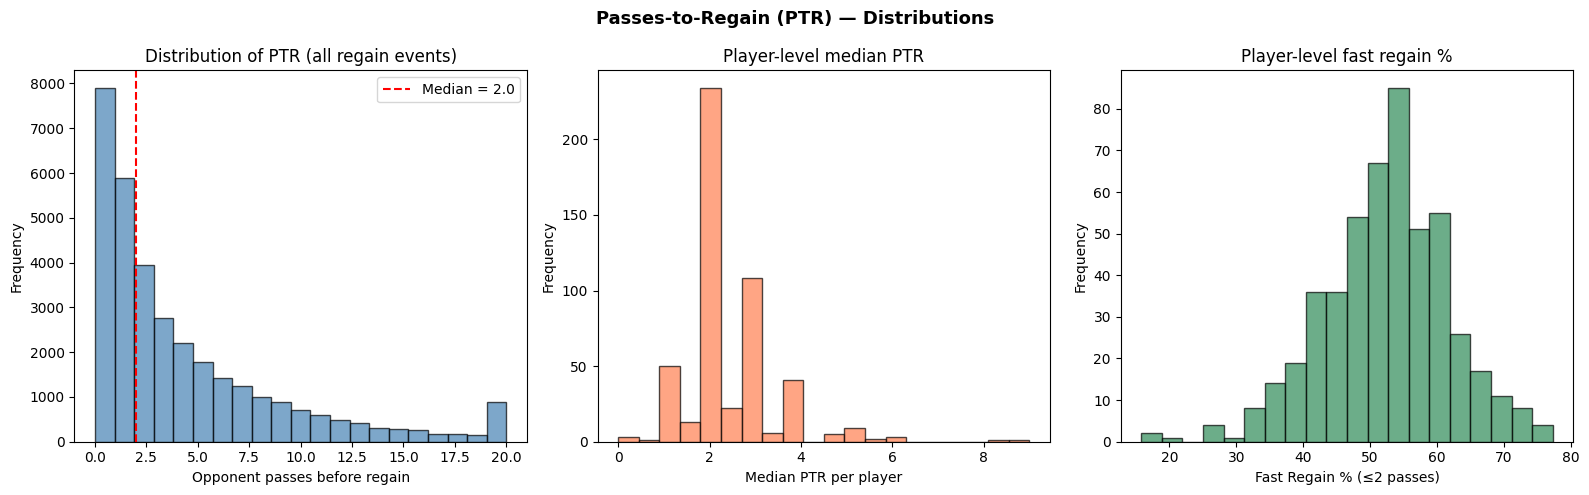

══════════════════════════════════════════════════════════════════════════════════════════
  TOP 20 DMs — UPDATED COMPOSITE WITH PASSES-TO-REGAIN (PTR)
══════════════════════════════════════════════════════════════════════════════════════════


,player_name,team_name,season,matches,composite_score,composite_score_v2,median_ptr,fast_regain_pct,n_regains,pillar_possession_regain,pillar_counter_pressing_v2,pillar_distribution_security
1,E. Barrenechea,Frosinone Calcio,2023_2024,31,83.03,83.75,1.0,63.7,190.0,82.74,89.93,68.65
0,M. de Roon,Atalanta Bergamasca Calcio,2021_2022,25,84.03,81.34,2.0,53.1,128.0,89.59,74.37,63.60
6,Lucas Leiva,SS Lazio,2021_2022,23,81.53,80.80,2.0,54.3,105.0,84.63,65.91,93.42
2,R. Freuler,Atalanta Bergamasca Calcio,2021_2022,29,82.69,80.33,2.0,60.4,169.0,93.51,86.68,59.82
12,J. Schouten,Bologna FC 1909,2022_2023,28,77.87,80.22,1.0,60.4,182.0,94.36,77.71,62.48
4,M. Frendrup,Genoa CFC,2024_2025,34,82.13,79.97,2.0,54.7,179.0,90.37,73.01,66.22
7,M. Hjulmand,US Lecce,2022_2023,35,80.84,78.64,2.0,50.6,265.0,98.04,67.92,33.33
13,M. Badelj,Genoa CFC,2021_2022,24,77.78,77.80,1.0,61.8,170.0,94.02,92.65,25.68
9,R. Krunić,AC Milan,2022_2023,18,79.23,77.10,2.0,54.4,103.0,81.59,74.06,83.56
8,A. Blin,US Lecce,2022_2023,26,79.64,76.68,2.0,53.2,124.0,85.17,75.64,46.31


In [14]:
# ── Cell 14: PTR distribution & integration into composite score ──────────────

# ── Visualize PTR distribution ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1) Histogram of individual regain events
axes[0].hist(ptr_raw["opp_passes_before_regain"].clip(upper=20), bins=21,
             edgecolor="black", alpha=0.7, color="steelblue")
axes[0].set_xlabel("Opponent passes before regain")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of PTR (all regain events)")
axes[0].axvline(ptr_raw["opp_passes_before_regain"].median(), color="red",
                ls="--", label=f'Median = {ptr_raw["opp_passes_before_regain"].median():.1f}')
axes[0].legend()

# 2) Median PTR per player
axes[1].hist(ptr_agg["median_ptr"], bins=20, edgecolor="black", alpha=0.7, color="coral")
axes[1].set_xlabel("Median PTR per player")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Player-level median PTR")

# 3) Fast regain % per player
axes[2].hist(ptr_agg["fast_regain_pct"], bins=20, edgecolor="black", alpha=0.7, color="seagreen")
axes[2].set_xlabel("Fast Regain % (≤2 passes)")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Player-level fast regain %")

plt.suptitle("Passes-to-Regain (PTR) — Distributions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── Merge PTR into scored DataFrame ──────────────────────────
ptr_merge = ptr_agg[["regain_player", "regain_player_id", "season",
                      "n_regains", "median_ptr", "mean_ptr", "fast_regain_pct"]].rename(
    columns={"regain_player": "player_name", "regain_player_id": "player_id"}
)

scored_with_ptr = scored.merge(
    ptr_merge, on=["player_name", "player_id", "season"], how="left"
)

# Percentile ranks for PTR metrics (lower median_ptr = better → invert)
scored_with_ptr["median_ptr_pct"] = 100 - scored_with_ptr["median_ptr"].rank(pct=True) * 100
scored_with_ptr["fast_regain_pct_pct"] = scored_with_ptr["fast_regain_pct"].rank(pct=True) * 100

# ── Updated counter-pressing pillar with PTR ─────────────────
# New pillar: 40% ball_rec_opp_half, 30% tackles_opp_half, 30% median_ptr
scored_with_ptr["pillar_counter_pressing_v2"] = (
    scored_with_ptr["ball_rec_opp_half_p90_pct"] * 0.30 +
    scored_with_ptr["tackles_opp_half_p90_pct"]  * 0.25 +
    scored_with_ptr["median_ptr_pct"].fillna(50)  * 0.25 +
    scored_with_ptr["fast_regain_pct_pct"].fillna(50) * 0.20
)

# ── Updated composite score ──────────────────────────────────
scored_with_ptr["composite_score_v2"] = (
    scored_with_ptr["pillar_possession_regain"]      * 0.40 +
    scored_with_ptr["pillar_positional_screening"]   * 0.25 +
    scored_with_ptr["pillar_counter_pressing_v2"]    * 0.20 +
    scored_with_ptr["pillar_distribution_security"]  * 0.15
)

scored_with_ptr = scored_with_ptr.sort_values("composite_score_v2", ascending=False)

# ── Show updated top 20 ─────────────────────────────────────
print("═" * 90)
print("  TOP 20 DMs — UPDATED COMPOSITE WITH PASSES-TO-REGAIN (PTR)")
print("═" * 90)
scored_with_ptr[[
    "player_name", "team_name", "season", "matches",
    "composite_score", "composite_score_v2",
    "median_ptr", "fast_regain_pct", "n_regains",
    "pillar_possession_regain", "pillar_counter_pressing_v2",
    "pillar_distribution_security",
]].head(20).round(2)

In [15]:
# ── Cell 15: Compare original vs PTR-enhanced rankings ───────────────────────

# Side-by-side: original rank vs new rank
comparison = scored_with_ptr[["player_name", "team_name", "season",
                               "composite_score", "composite_score_v2",
                               "median_ptr", "fast_regain_pct"]].copy()
comparison["rank_v1"] = comparison["composite_score"].rank(ascending=False).astype(int)
comparison["rank_v2"] = comparison["composite_score_v2"].rank(ascending=False).astype(int)
comparison["rank_change"] = comparison["rank_v1"] - comparison["rank_v2"]  # positive = moved UP
comparison = comparison.sort_values("rank_v2")

print("═" * 90)
print("  BIGGEST MOVERS — Players whose rank improved most with PTR")
print("═" * 90)
top_risers = comparison[comparison["rank_change"] > 0].sort_values("rank_change", ascending=False)
top_risers[["player_name", "team_name", "season", "rank_v1", "rank_v2",
            "rank_change", "median_ptr", "fast_regain_pct"]].head(15).round(1)

══════════════════════════════════════════════════════════════════════════════════════════
  BIGGEST MOVERS — Players whose rank improved most with PTR
══════════════════════════════════════════════════════════════════════════════════════════


,player_name,team_name,season,rank_v1,rank_v2,rank_change,median_ptr,fast_regain_pct
297,Y. Engelhardt,Calcio Como 1907,2024_2025,298,246,52,1.0,68.8
248,Marcos Antônio,SS Lazio,2022_2023,249,198,51,1.0,71.0
218,T. Rincón,UC Sampdoria,2021_2022,219,169,50,1.0,61.0
156,Miguel Veloso,Hellas Verona FC,2021_2022,157,112,45,1.0,66.3
258,I. Ilić,Hellas Verona FC,2022_2023,259,216,43,1.0,63.8
185,M. Hongla,Hellas Verona FC,2023_2024,186,143,43,1.0,64.1
135,I. Ilić,Hellas Verona FC,2022_2023,136,94,42,1.0,63.8
222,S. Lobotka,SSC Napoli,2025_2026,223,183,40,1.5,59.7
144,A. Blin,US Lecce,2023_2024,145,105,40,1.0,64.8
237,N. Moro,Bologna FC 1909,2023_2024,238,199,39,1.0,67.6


## Interpretation & Next Steps

### How to read the results
- **Composite Score** (0–100): the higher, the better the player matches the ball-winning DM profile
- **Pillar scores** are weighted percentile averages within each category
- Players must pass **all thresholds**: Possession Regain ≥ 70th pct, Distribution ≥ 50th pct, no single defensive KPI below 40th pct

### Limitations
- **Minutes estimation** is approximate (based on last event timestamp per match, not actual substitution tracking)
- **Position tags** (`CDM`, `MC`) come from Opta formation data — some players may shift positions mid-match
- **Counter-pressing** is approximated via ball recoveries/tackles in the opponent half, not via time-to-regain sequences
- Data covers **Serie A only** — profiles may differ in other leagues

### Possible extensions
- Add **time-to-regain** metric (seconds between possession loss and recovery by same team)
- Include **progressive passes** to distinguish DMs who can also build play
- Cross-reference with **market value** or **contract data** for recruitment use
- Expand to **multi-league** comparison (e.g., Bundesliga, La Liga)